## Network Analysis

## Purpose: 

{TODO}

In [22]:
import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.width', 10000000)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import glob
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

from gprofiler import GProfiler
import randomcolor

import pickle

In [2]:
nx.__version__

'3.1'

## Thresholds

In [3]:
# thresholds for relative scores for each transcription factor used 
# NOTE: 900 = 90th percentile and so on
relative_threshold = [900, 950, 990]

# thresholds for how far upstream of TSS was used
upstream_thresholds = ["750", "2500", "5000"]

## Load Data

In [4]:
mouse_tfs = pd.read_csv("../../../../inputs/mouse_tfs/Mus_musculus_TF.txt", sep="\t")
mouse_tfs = mouse_tfs.set_index("Ensembl")

mouse_tfs.head()

,Species,Symbol,Family,Protein,Entrez_ID
Ensembl,,,,,
ENSMUSG00000063804,Mus_musculus,Lin28b,CSD,ENSMUSP00000078361.7;,380669.0
ENSMUSG00000000093,Mus_musculus,Tbx2,T-box,ENSMUSP00000000095.7;,21385.0
ENSMUSG00000042508,Mus_musculus,Dmtf1,MYB,ENSMUSP00000071815.6;ENSMUSP00000139361.2;ENSM...,23857.0
ENSMUSG00000021604,Mus_musculus,Irx4,Homeobox,ENSMUSP00000134738.2;ENSMUSP00000022095.8;,50916.0
ENSMUSG00000003184,Mus_musculus,Irf3,IRF,ENSMUSP00000146773.2;ENSMUSP00000146383.2;ENSM...,54131.0


In [5]:
sunny_diff_exp = pd.read_excel("../../../../inputs/sunny_differential_analysis/mRNA-level-E9-5_Rbfox2_KO-Het.xlsx")
sunny_diff_exp.head()

,ENSMUSG,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_id
0,ENSMUSG00000017950,219.709303,-4.693934,0.867171,-5.412926,6.200306e-08,2.998404e-05,Hnf4a
1,ENSMUSG00000028357,70.833068,-4.668388,0.678707,-6.878359,6.054593e-12,8.783817e-09,Kif12
2,ENSMUSG00000040891,83.085759,-4.616412,0.574760,-8.031891,9.598124e-16,2.262758e-12,Foxa3
3,ENSMUSG00000017344,325.121362,-4.357324,1.097967,-3.968539,7.231450e-05,8.265767e-03,Vtn
4,ENSMUSG00000020609,246.446133,-4.086230,1.030140,-3.966674,7.288267e-05,8.280525e-03,Apob


In [6]:
annotation_tables = {}

for file in sorted(glob.glob("../../5_transcripts_to_genes/outputs/*")): 
    
    annotation_tables[file.split("/")[-1].split(".tsv")[0]] = pd.read_csv(
        file, 
        sep="\t",
        compression="gzip"
    )

#### Remove rows that are not annotated to any genes

In [7]:
for key in annotation_tables:
    tmp = annotation_tables[key].dropna(axis=0)
    annotation_tables[key] = tmp 
    
    tmp.index.size
    

1736975

2702262

714857

1399786

2088167

...

4115608

1947385

331670

539458

135938

## Differential Expression Volcano Plot

Need to use this to decide thresholds for `p-values` and `log-fold changes`

In [8]:
sunny_diff_exp.sort_values(by=["log2FoldChange"])

,ENSMUSG,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_id
0,ENSMUSG00000017950,219.709303,-4.693934,0.867171,-5.412926,6.200306e-08,2.998404e-05,Hnf4a
1,ENSMUSG00000028357,70.833068,-4.668388,0.678707,-6.878359,6.054593e-12,8.783817e-09,Kif12
2,ENSMUSG00000040891,83.085759,-4.616412,0.574760,-8.031891,9.598124e-16,2.262758e-12,Foxa3
3,ENSMUSG00000017344,325.121362,-4.357324,1.097967,-3.968539,7.231450e-05,8.265767e-03,Vtn
4,ENSMUSG00000020609,246.446133,-4.086230,1.030140,-3.966674,7.288267e-05,8.280525e-03,Apob
5,ENSMUSG00000032083,148.007564,-3.967003,1.087712,-3.647108,2.652080e-04,2.092813e-02,Apoa1
6,ENSMUSG00000042448,76.541425,-3.562479,0.739478,-4.817559,1.453251e-06,3.754563e-04,Hoxd1
7,ENSMUSG00000071551,53.717206,-3.360255,0.795119,-4.226104,2.377716e-05,3.736977e-03,Akr1c19
8,ENSMUSG00000074768,53.882981,-3.329224,0.756409,-4.401353,1.075779e-05,1.950091e-03,Bhmt
9,ENSMUSG00000045518,107.826620,-3.289715,0.457581,-7.189357,6.509719e-13,1.227733e-09,Onecut3


In [9]:
sunny_diff_exp.sort_values(by=["padj"])

,ENSMUSG,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_id
327,ENSMUSG00000034009,412.067179,2.811033,0.243924,11.524228,9.960137e-31,1.878482e-26,Rxfp1
20,ENSMUSG00000042453,4135.717257,-2.232809,0.212768,-10.494104,9.194560e-26,8.670470e-22,Reln
316,ENSMUSG00000029019,9698.209515,2.139324,0.209991,10.187674,2.250844e-24,1.415031e-20,Nppb
62,ENSMUSG00000033565,15194.864445,-0.994187,0.100046,-9.937295,2.865000e-23,1.350848e-19,Rbfox2
305,ENSMUSG00000019997,3414.818470,1.729922,0.187888,9.207206,3.347254e-20,1.262584e-16,Ctgf
27,ENSMUSG00000032796,6073.502354,-1.753570,0.194733,-9.004976,2.157138e-19,6.780603e-16,Lama1
30,ENSMUSG00000064225,579.231333,-1.696702,0.207723,-8.168096,3.132958e-16,8.441083e-13,Paqr9
2,ENSMUSG00000040891,83.085759,-4.616412,0.574760,-8.031891,9.598124e-16,2.262758e-12,Foxa3
303,ENSMUSG00000021367,1094.631314,1.674451,0.223828,7.480987,7.376673e-14,1.545823e-10,Edn1
9,ENSMUSG00000045518,107.826620,-3.289715,0.457581,-7.189357,6.509719e-13,1.227733e-09,Onecut3


In [10]:
print((-np.log10(sunny_diff_exp["padj"])).to_list(), end=" ")

[4.5231098261397555, 8.056316730794935, 11.645361936707092, 2.082716859072109, 2.0819421039154715, 1.679269538712776, 3.425440654703709, 2.427479527258278, 2.709945074478188, 8.91089603868426, 4.659761413076896, 3.8950279951239213, 5.180543139190678, 2.709945074478188, 7.461313031492753, 8.222699701747318, 2.9580712830076155, 3.4488026277346018, 2.709945074478188, 4.946585944231198, 21.061957339233086, 2.113468626749609, 5.358044805997621, 3.812867206663029, 2.281625483444382, 1.4139741632170122, 2.324884338875013, 15.168731656029902, 1.6069560275304902, 2.0489804118509563, 12.073601832250198, 2.709945074478188, 3.4059374775120985, 3.373027024268697, 2.281625483444382, 2.1570404494130724, 3.8880097701223018, 6.108163822062688, 3.425440654703709, 1.4144903518706042, 4.751042982581231, 1.7199128566300566, 5.1296912030808155, 1.349335168896332, 7.755590049957611, 4.163852104502328, 2.0489804118509563, 4.875349725727527, 5.6713774134749055, 4.371272262623068, 2.295523659018942, 1.375984729

<Figure size 1200x800 with 0 Axes>

Text(0.5, 1.0, "Volcano Plot of Sunny's Differential Expression Analysis")

Text(0, 0.5, '-log10(Adjusted P-Value)')

Text(0.5, 0, 'log2(Fold-Change)')

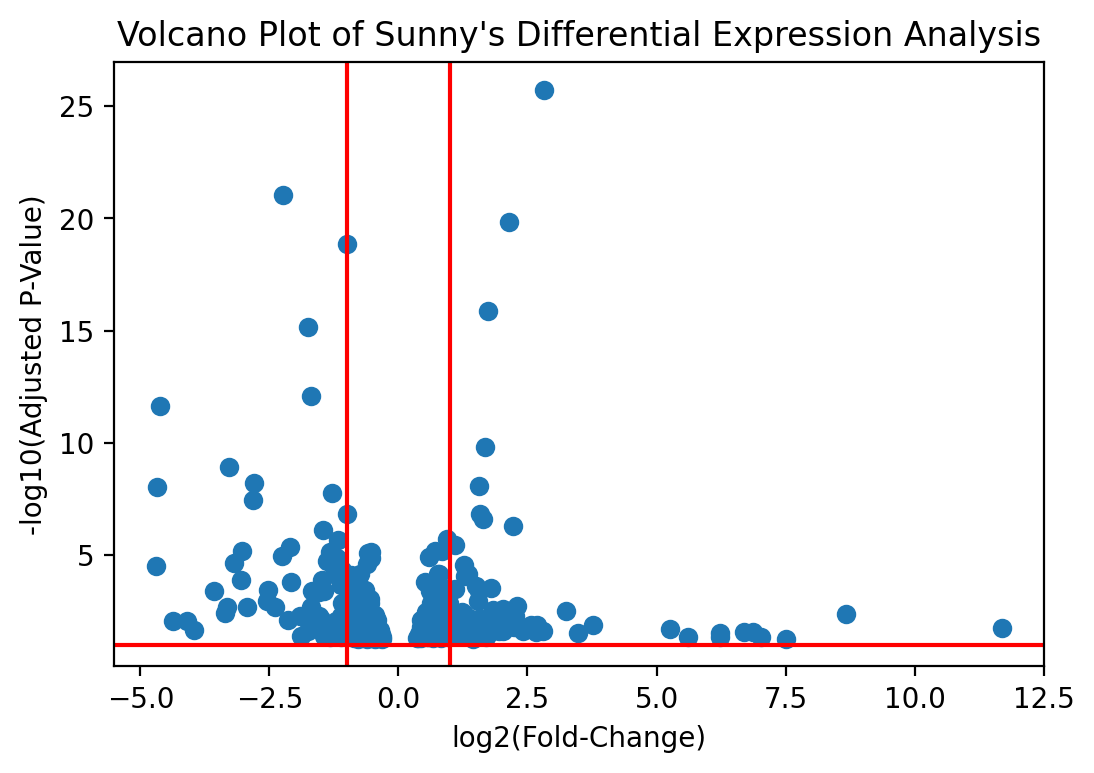

In [11]:
plt.figure(dpi=200)

plt.title("Volcano Plot of Sunny's Differential Expression Analysis")
plt.scatter(x=sunny_diff_exp["log2FoldChange"], y=-np.log10(sunny_diff_exp["padj"]))

plt.ylabel("-log10(Adjusted P-Value)")
plt.xlabel("log2(Fold-Change)")

plt.axvline(1, color="red", label="1")
plt.axvline(-1, color="red", label="-1")

plt.axhline(1, color='red', label="1")

#### Save differential expression `ENSEMBL` IDs

In [12]:
diff_gene_ids = sunny_diff_exp["ENSMUSG"].tolist()

print(diff_gene_ids,end="\t")

['ENSMUSG00000017950', 'ENSMUSG00000028357', 'ENSMUSG00000040891', 'ENSMUSG00000017344', 'ENSMUSG00000020609', 'ENSMUSG00000032083', 'ENSMUSG00000042448', 'ENSMUSG00000071551', 'ENSMUSG00000074768', 'ENSMUSG00000045518', 'ENSMUSG00000019368', 'ENSMUSG00000038700', 'ENSMUSG00000029195', 'ENSMUSG00000044254', 'ENSMUSG00000026398', 'ENSMUSG00000005320', 'ENSMUSG00000020679', 'ENSMUSG00000029556', 'ENSMUSG00000037025', 'ENSMUSG00000005681', 'ENSMUSG00000042453', 'ENSMUSG00000024391', 'ENSMUSG00000045991', 'ENSMUSG00000030088', 'ENSMUSG00000026227', 'ENSMUSG00000026934', 'ENSMUSG00000073409', 'ENSMUSG00000032796', 'ENSMUSG00000031654', 'ENSMUSG00000031883', 'ENSMUSG00000064225', 'ENSMUSG00000028373', 'ENSMUSG00000055409', 'ENSMUSG00000038692', 'ENSMUSG00000021209', 'ENSMUSG00000034450', 'ENSMUSG00000025196', 'ENSMUSG00000079654', 'ENSMUSG00000024907', 'ENSMUSG00000048126', 'ENSMUSG00000020080', 'ENSMUSG00000102692', 'ENSMUSG00000074575', 'ENSMUSG00000018822', 'ENSMUSG00000024986', 'ENSMUSG0

## Construct Edgelist

Need to make sure that transcription factor names coming from Sunny's list actually have `GENCODE` IDs. 

This is because we want to avoid situations where the TF in question is named something else in `GENCODE` so we're missing links. 

In [13]:
for key in annotation_tables: 
    # don't get repeat entries due to different thresholds used for annotation
    if "5000" in key: 
        annotation_tables[key]["1"].unique()

array(['MEF2A'], dtype=object)

array(['RORA'], dtype=object)

array(['RREB1'], dtype=object)

array(['ELK4'], dtype=object)

array(['NFIC'], dtype=object)

...

array(['NR4A1'], dtype=object)

array(['PBX3'], dtype=object)

array(['TCF7L1'], dtype=object)

array(['MAZ'], dtype=object)

array(['NR6A1'], dtype=object)

The above `TFs` besides `RORA` are part of `GENCODE`. 

`RORA` is from `RefSeq`. 

In [14]:
individual_edge_lists = {}

for key in annotation_tables:
    
    key 
    
    # rename columns
    tmp = annotation_tables[key][["1", "Gene name", "Gene stable ID", "2"]].rename(
        columns={"1":"TF", "Gene name":"Target", "Gene stable ID": "Target ID", "2": "Relative Score"}
    )

    # make gene names lowercase to avoid weird issues where there are duplicate nodes (due to capitalization issues)
    tmp["TF"] = tmp["TF"].str.lower()
    tmp["Target"] =  tmp["Target"].str.lower()
    
    # for each threshold in relative scoring
    for threshold in relative_threshold: 
        
        # subset relative scores for thresholds
        tmp = tmp[tmp["Relative Score"]>threshold]
        
        # create key for edge list 
        edge_list_key = "{}_relative_score_percentile_{}".format(key, threshold)
        
        # get the unique TF-target pairs 
        individual_edge_lists[edge_list_key] = tmp[["TF", "Target", "Target ID"]].drop_duplicates()
    

'MA0052.4.upstream_2500'

'MA0052.4.upstream_5000'

'MA0052.4.upstream_750'

'MA0071.1.upstream_2500'

'MA0071.1.upstream_5000'

...

'MA1522.1.upstream_5000'

'MA1522.1.upstream_750'

'MA1541.1.upstream_2500'

'MA1541.1.upstream_5000'

'MA1541.1.upstream_750'

Concatenate all lists that have the same upstream parameter and relative score threshold

In [15]:
final_edge_lists = {}

for score_threshold in relative_threshold: 
    for upstream_threshold in upstream_thresholds:
        edge_list_key = "upstream_{}_score_{}".format(upstream_threshold, score_threshold)
        final_edge_lists[edge_list_key] = []
        
        for key in individual_edge_lists: 
            if str(score_threshold) in key and str(upstream_threshold) in key: 
                final_edge_lists[edge_list_key].append(individual_edge_lists[key])
    
    
for key in final_edge_lists:
    key
    final_edge_lists[key] = pd.concat(final_edge_lists[key])
    final_edge_lists[key] = final_edge_lists[key].set_index("Target ID")
    final_edge_lists[key].index.size


'upstream_750_score_900'

162423

'upstream_2500_score_900'

240359

'upstream_5000_score_900'

...

7381

'upstream_2500_score_990'

13964

'upstream_5000_score_990'

20648

Check number of gene targets per combination of parameters

In [16]:
unique_gene_numbers = []

for key in final_edge_lists: 
    key
    final_edge_lists[key]["Target"].unique().size
    unique_gene_numbers.append(final_edge_lists[key]["Target"].unique().size)
    
unique_gene_numbers

'upstream_750_score_900'

19465

'upstream_2500_score_900'

19528

'upstream_5000_score_900'

...

'upstream_2500_score_990'

9058

'upstream_5000_score_990'

11613

[19465, 19528, 19584, 17737, 19296, 19535, 5768, 9058, 11613]

<Figure size 1200x800 with 0 Axes>

Text(0.5, 0, 'Upstream of TSS by')

Text(0, 0.5, 'Number of Unique Protein-coding Genes')

([<matplotlib.axis.XTick at 0x7f895f24b3a0>,
 [Text(0.25, 0, '750'), Text(1.25, 0, '2500'), Text(2.25, 0, '5000')])

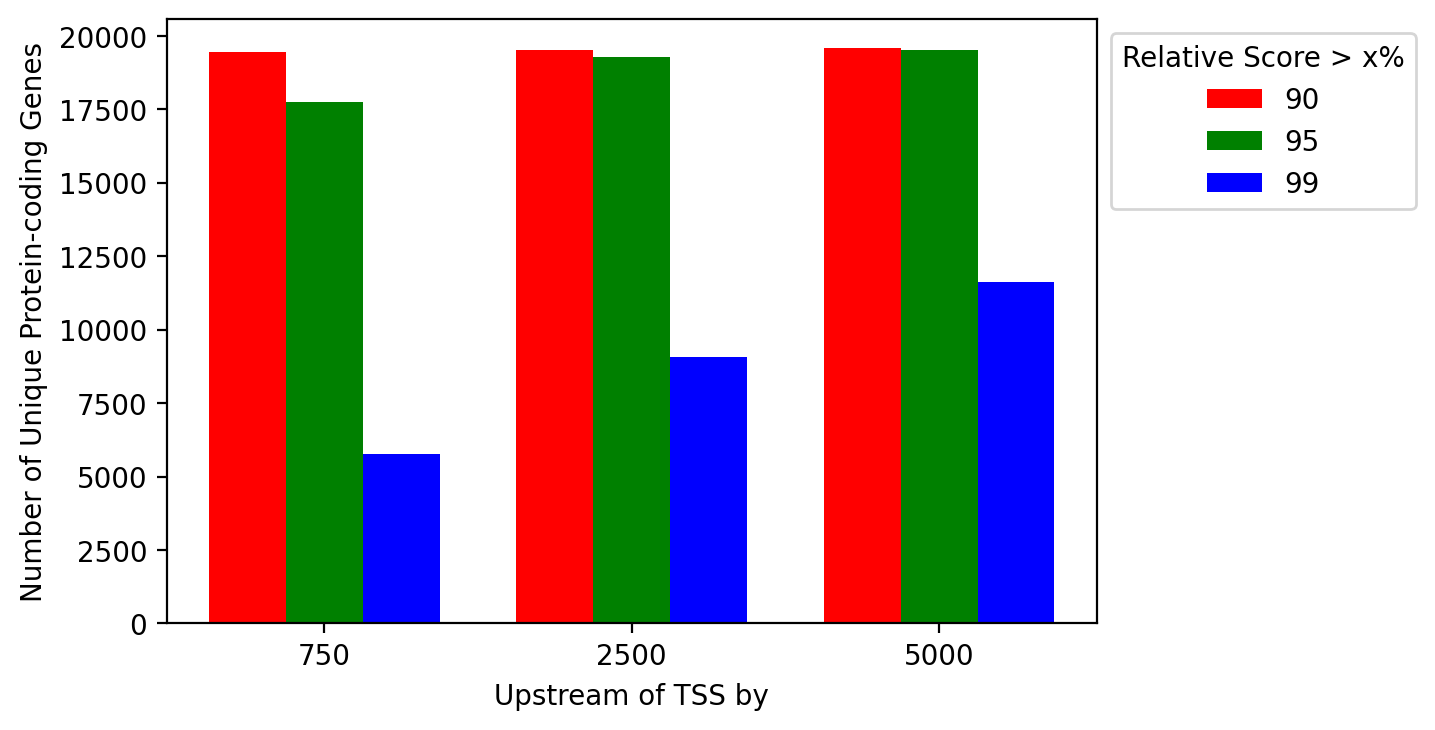

In [17]:
plt.figure(dpi=200)

N = 3
ind = np.arange(N) 
width = 0.25
  
bar1 = plt.bar(ind, unique_gene_numbers[0:3], width, color = 'r')
bar2 = plt.bar(ind+width, unique_gene_numbers[3:6], width, color='g')
bar3 = plt.bar(ind+width*2, unique_gene_numbers[6:9], width, color = 'b')
  
plt.xlabel("Upstream of TSS by")
plt.ylabel('Number of Unique Protein-coding Genes')
  
plt.xticks(ind+width,["750", "2500", "5000"])
plt.legend( (bar1, bar2, bar3), ('90', '95', '99'), title="Relative Score > x%", bbox_to_anchor=(1,1))
plt.show()

## GO Enrichment

In [18]:
genes_for_GO = final_edge_lists['upstream_750_score_990']["Target"].unique().tolist()

for item in genes_for_GO: 
    print(item, end = "\t")

tbp	psmb1	bhlhe40	6430548m08rik	sec24d	zfpm2	glrp1	plppr3	nckap5	amn1	tuba1a	nsd1	dip2b	myo5a	galnt2l	gm49450	prtn3	bex6	col6a1	col6a2	ergic1	ifrd1	celf2	scrib	aven	rps6ka1	psap	ndrg2	trim28	pcdhac1	sptbn4	dnajc7	cox6c	lamp2	serinc3	myh4	smpdl3a	dusp6	obscn	glrx	4930578i06rik	pabpn1	laptm4b	pak2	lmln	paxbp1	msrb2	cfb	lipf	eif3a	katnal2	gigyf2	bok	acbd3	ptpn14	ubox5	hdc	mrgbp	ppm1l	casp6	ccdc107	ssu72	gbp8	pcolce	fbxo24	emc3	ttc23	gm42742	aldoa	art1	gas6	mfap3l	crispld2	pou2af1	me1	bsn	acsl3	nfatc1	fancd2	prex1	dock4	ppp1r16a	heca	trpm3	ptprm	smpx	trrap	sufu	actr1a	h2-aa	mycbpap	aox3	tm6sf1	naa25	camk4	bcor	hnrnpul1	ago2	gramd1b	lzts3	elmsan1	tgtp2	misp	pdgfa	rdh7	rnf126	pcdhac2	pcdha12	metap2	coro2b	bsdc1	gtdc1	snx10	rnf125	cystm1	prop1	akt2	mtus1	morn4	prss54	zbtb6	rnf216	utp14b	pcdhb17	sipa1l1	zfp444	ppm1e	kcns3	themis	oprd1	olfr56	cog7	rp1l1	npsr1	gm12185	tmtc1	clec4a1	tmem248	gpr141	shisa6	ccser2	amy1	tgtp1	nyap2	susd6	irs1	atp8b2	efemp2	pcdha1	alg13	etnppl	ms4a10	gtf2ird1	atxn7l3	

#### Results

Doesn't seem like it actually means anything 

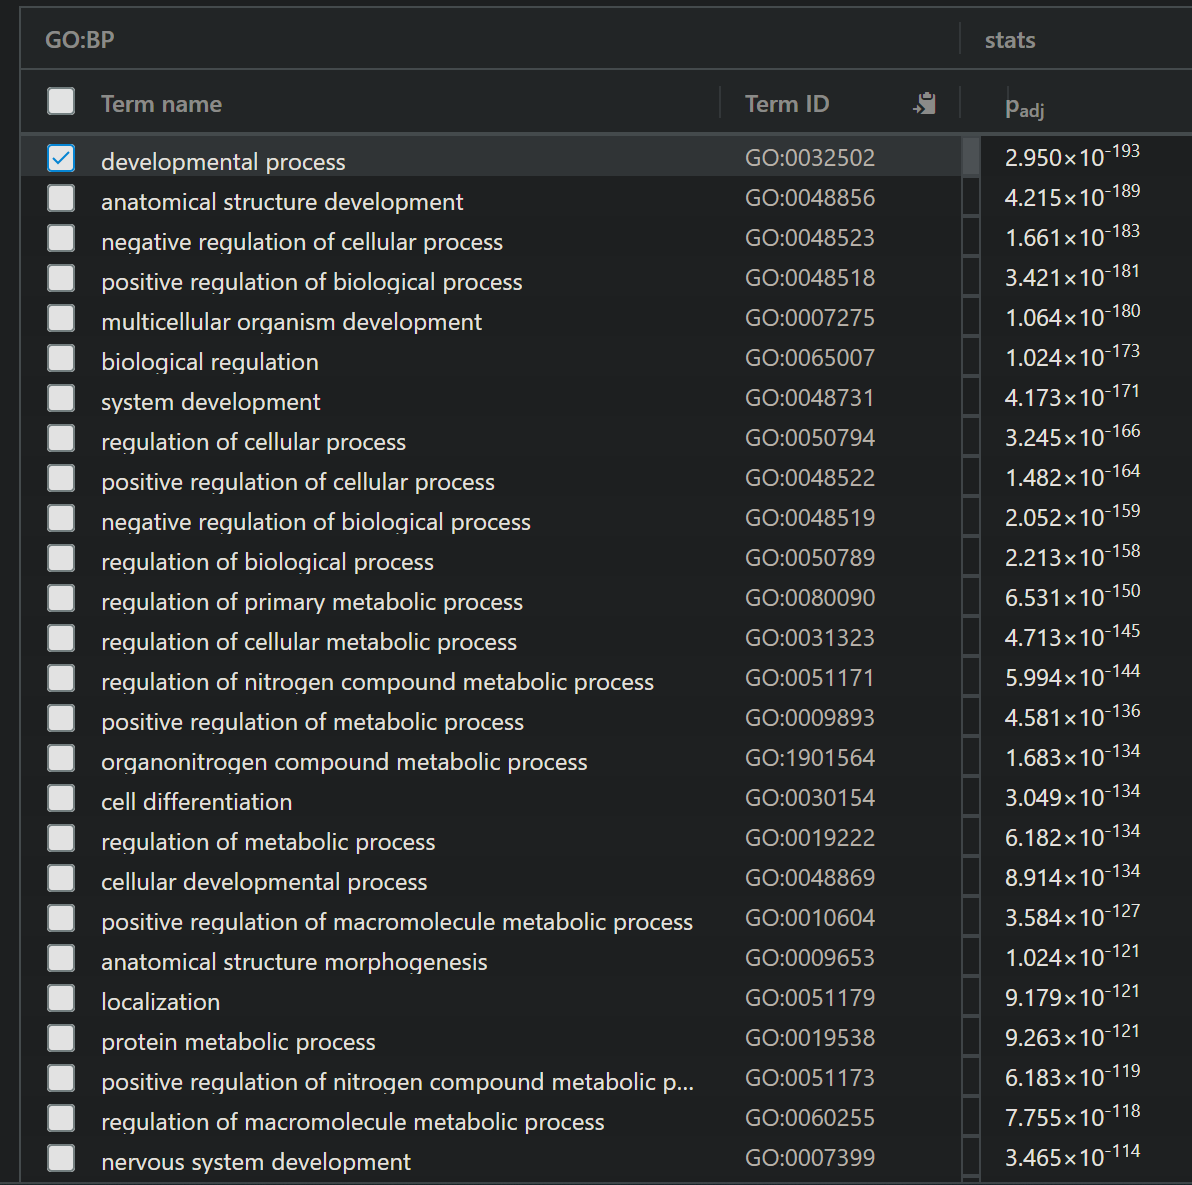

## Subset to Differentially Expressed Genes 

In [19]:
joined_final_edge_lists = {}

for key in final_edge_lists: 
    key
    
    tmp = final_edge_lists[key].join(pd.DataFrame(diff_gene_ids).set_index(0), how="inner")
    
    joined_final_edge_lists[key] = tmp 
    
    tmp.index.size

'upstream_750_score_900'

2936

'upstream_2500_score_900'

4075

'upstream_5000_score_900'

...

161

'upstream_2500_score_990'

306

'upstream_5000_score_990'

452

'upstream_750_score_900'

312

'upstream_2500_score_900'

312

'upstream_5000_score_900'

...

225

<Figure size 1200x800 with 0 Axes>

Text(0.5, 0, 'Upstream of TSS by')

Text(0, 0.5, '% of Diff. Expression Genes as TF Targets ')

([<matplotlib.axis.XTick at 0x7f88f10f88e0>,
 [Text(0.25, 0, '750'), Text(1.25, 0, '2500'), Text(2.25, 0, '5000')])

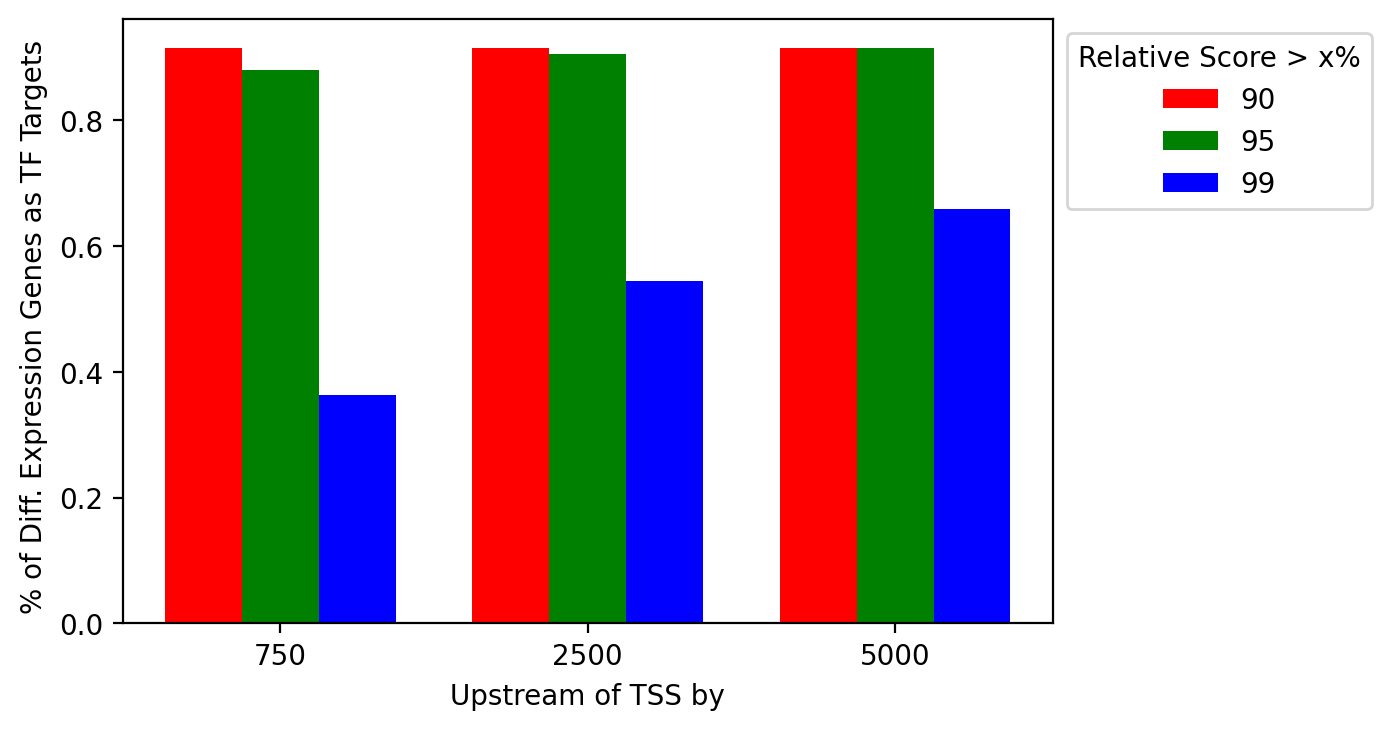

In [20]:
unique_gene_numbers = []

for key in joined_final_edge_lists: 
    key
    joined_final_edge_lists[key]["Target"].unique().size
    unique_gene_numbers.append((joined_final_edge_lists[key]["Target"].unique().size)/len(diff_gene_ids))
    

plt.figure(dpi=200)

N = 3
ind = np.arange(N) 
width = 0.25
  
bar1 = plt.bar(ind, unique_gene_numbers[0:3], width, color = 'r')
bar2 = plt.bar(ind+width, unique_gene_numbers[3:6], width, color='g')
bar3 = plt.bar(ind+width*2, unique_gene_numbers[6:9], width, color = 'b')
  
plt.xlabel("Upstream of TSS by")
plt.ylabel('% of Diff. Expression Genes as TF Targets ')
  
plt.xticks(ind+width,["750", "2500", "5000"])
plt.legend( (bar1, bar2, bar3), ('90', '95', '99'), title="Relative Score > x%", bbox_to_anchor=(1,1))
plt.show()

## Initialize Networks

<Figure size 1800x1200 with 0 Axes>

Text(0.5, 1.0, 'upstream_750_score_900')

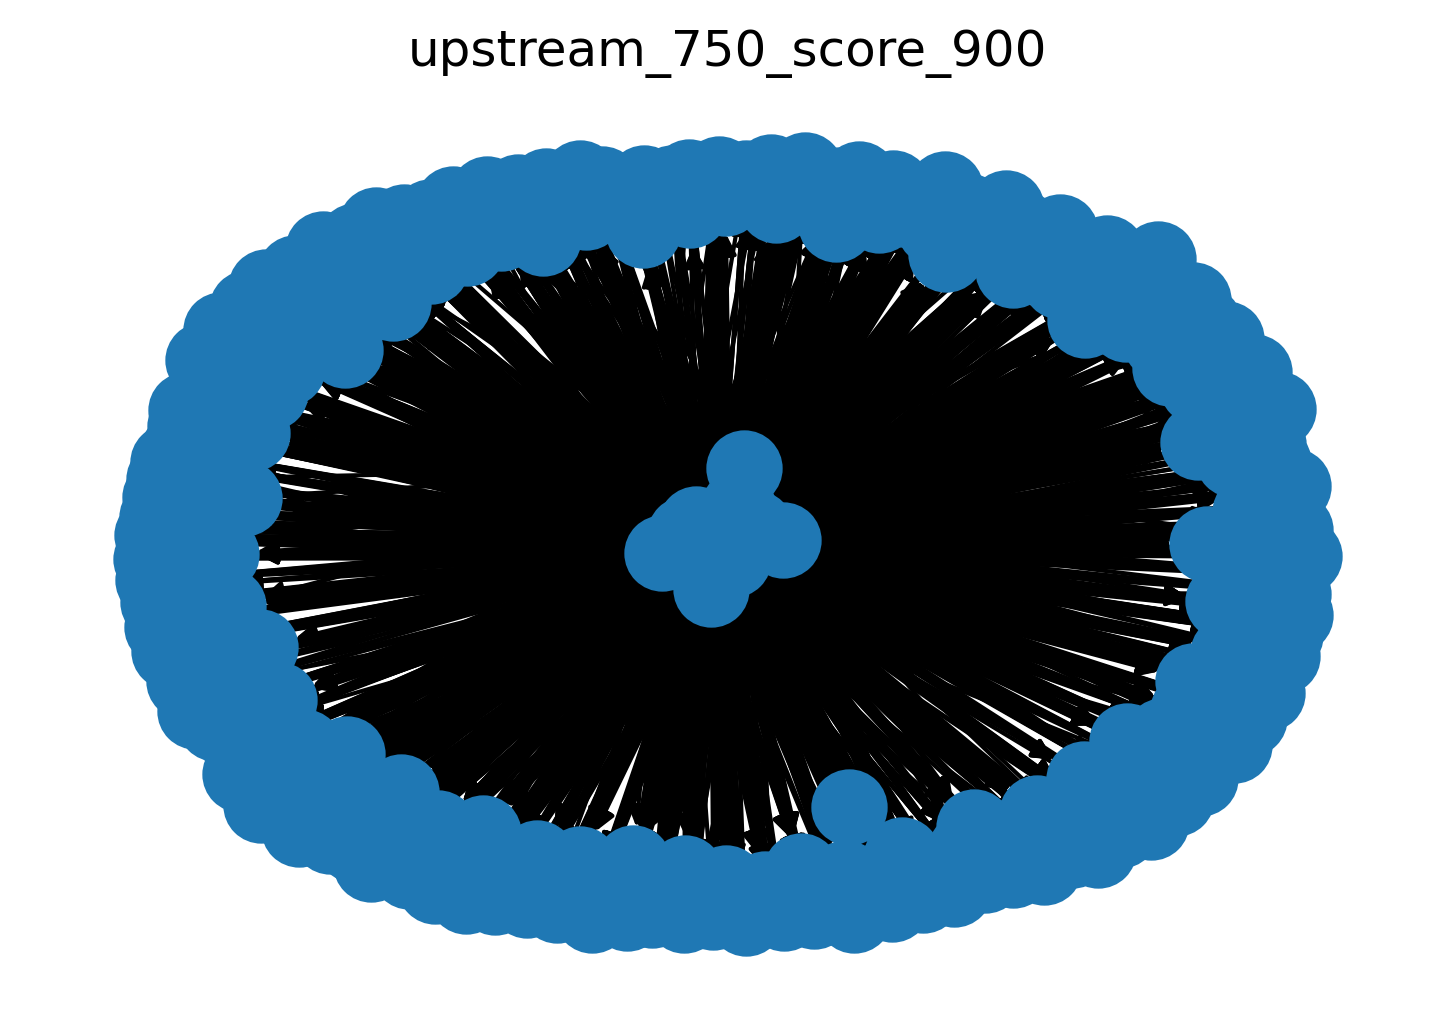

<Figure size 1800x1200 with 0 Axes>

Text(0.5, 1.0, 'upstream_2500_score_900')

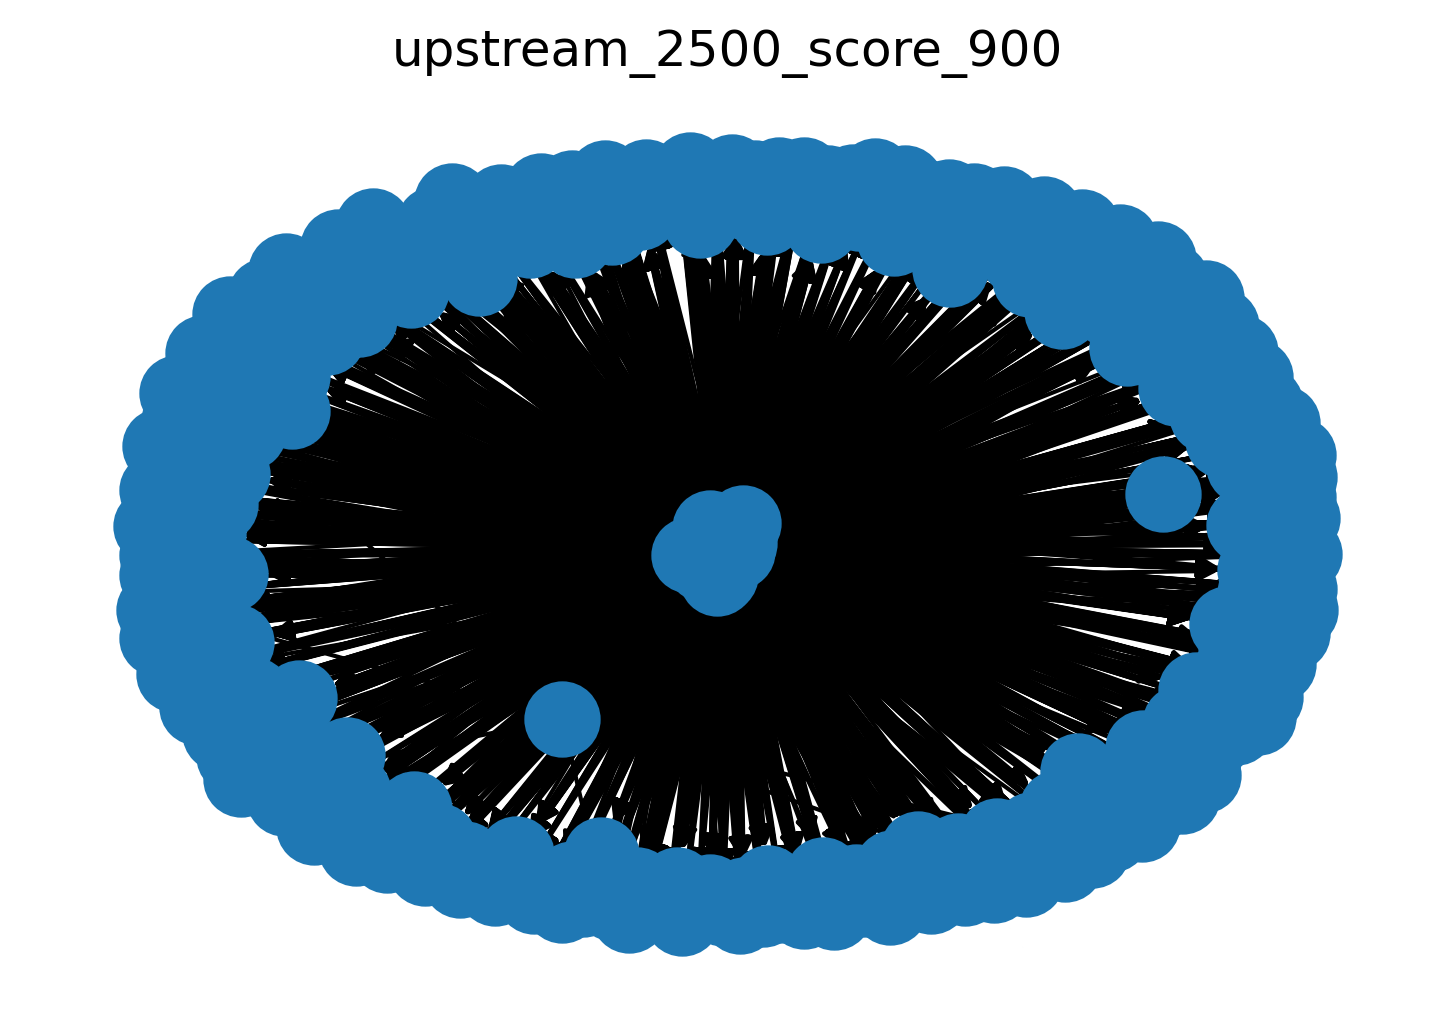

<Figure size 1800x1200 with 0 Axes>

Text(0.5, 1.0, 'upstream_5000_score_900')

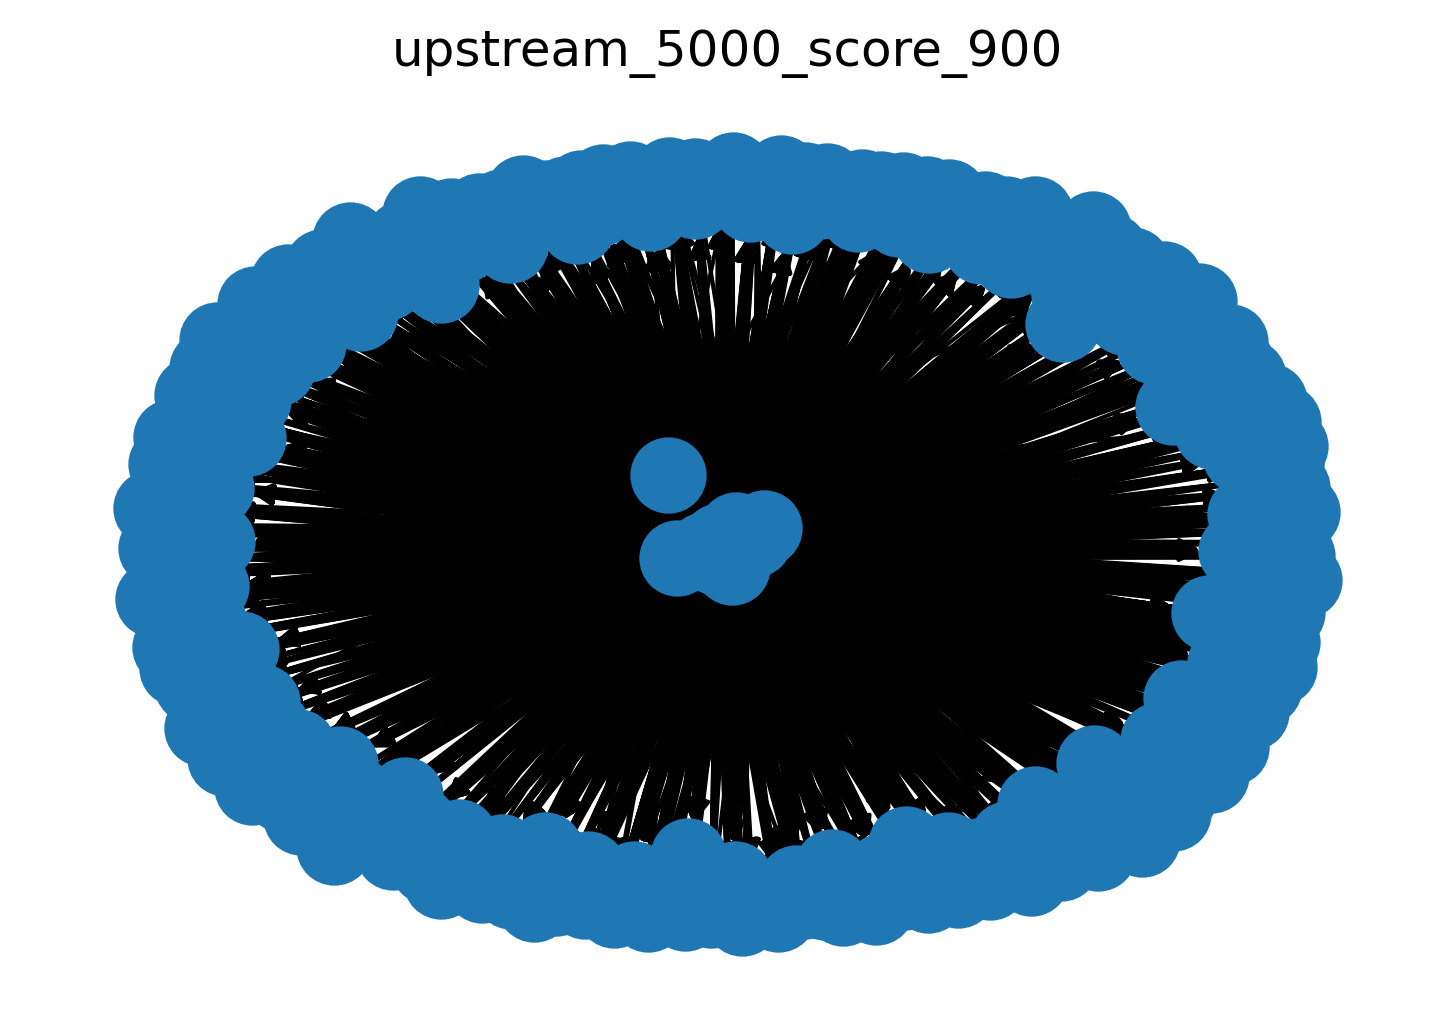

<Figure size 1800x1200 with 0 Axes>

Text(0.5, 1.0, 'upstream_750_score_950')

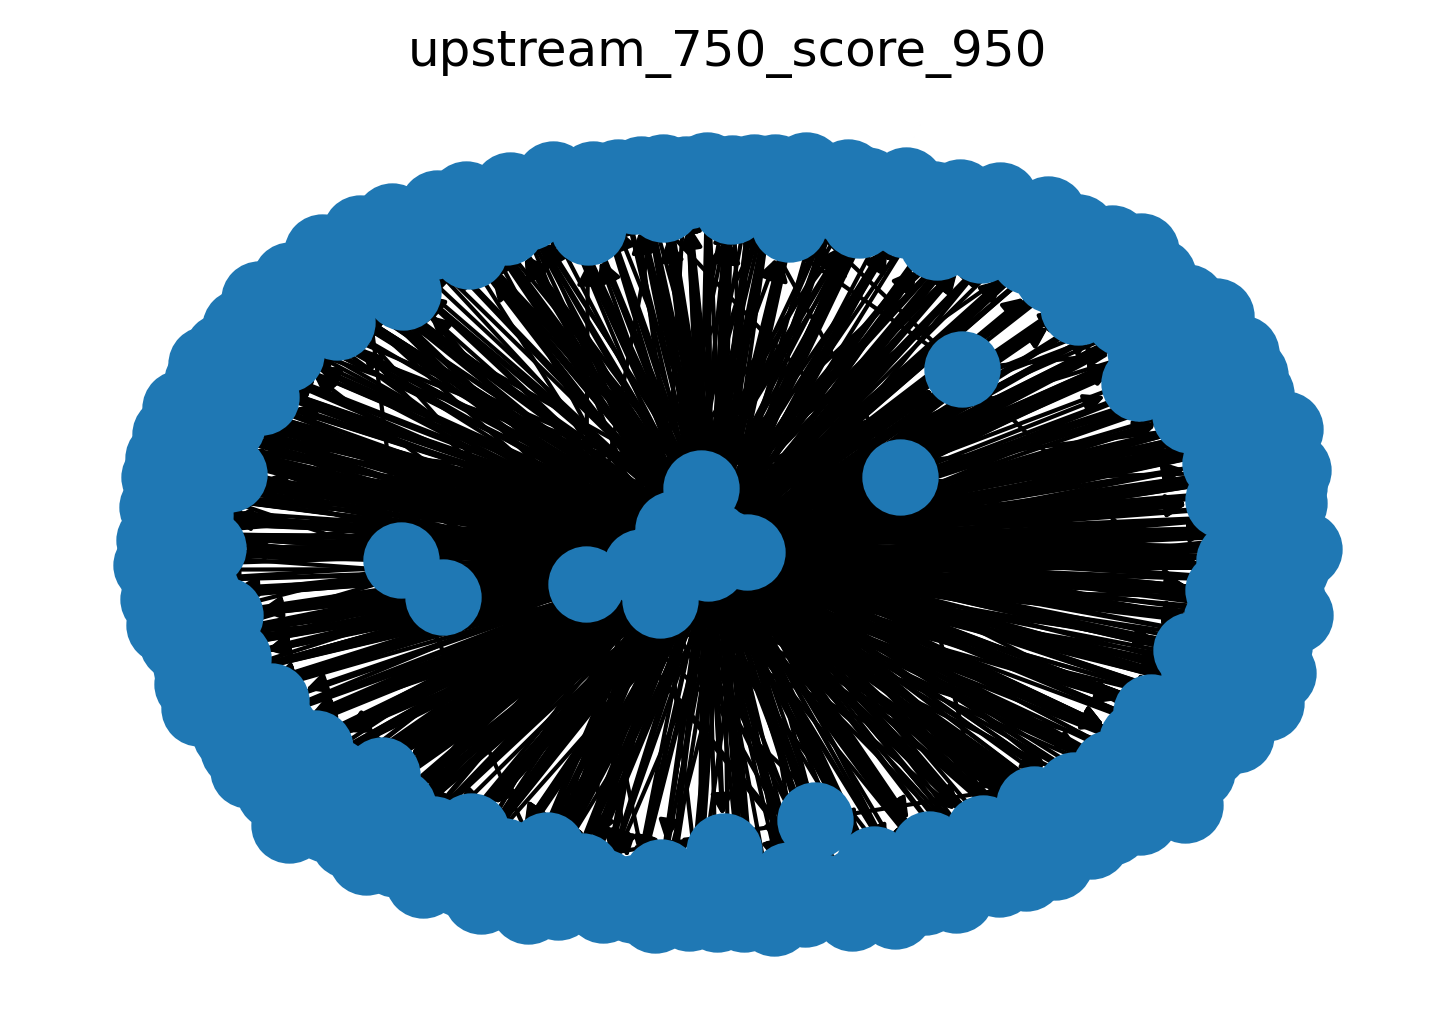

<Figure size 1800x1200 with 0 Axes>

Text(0.5, 1.0, 'upstream_2500_score_950')

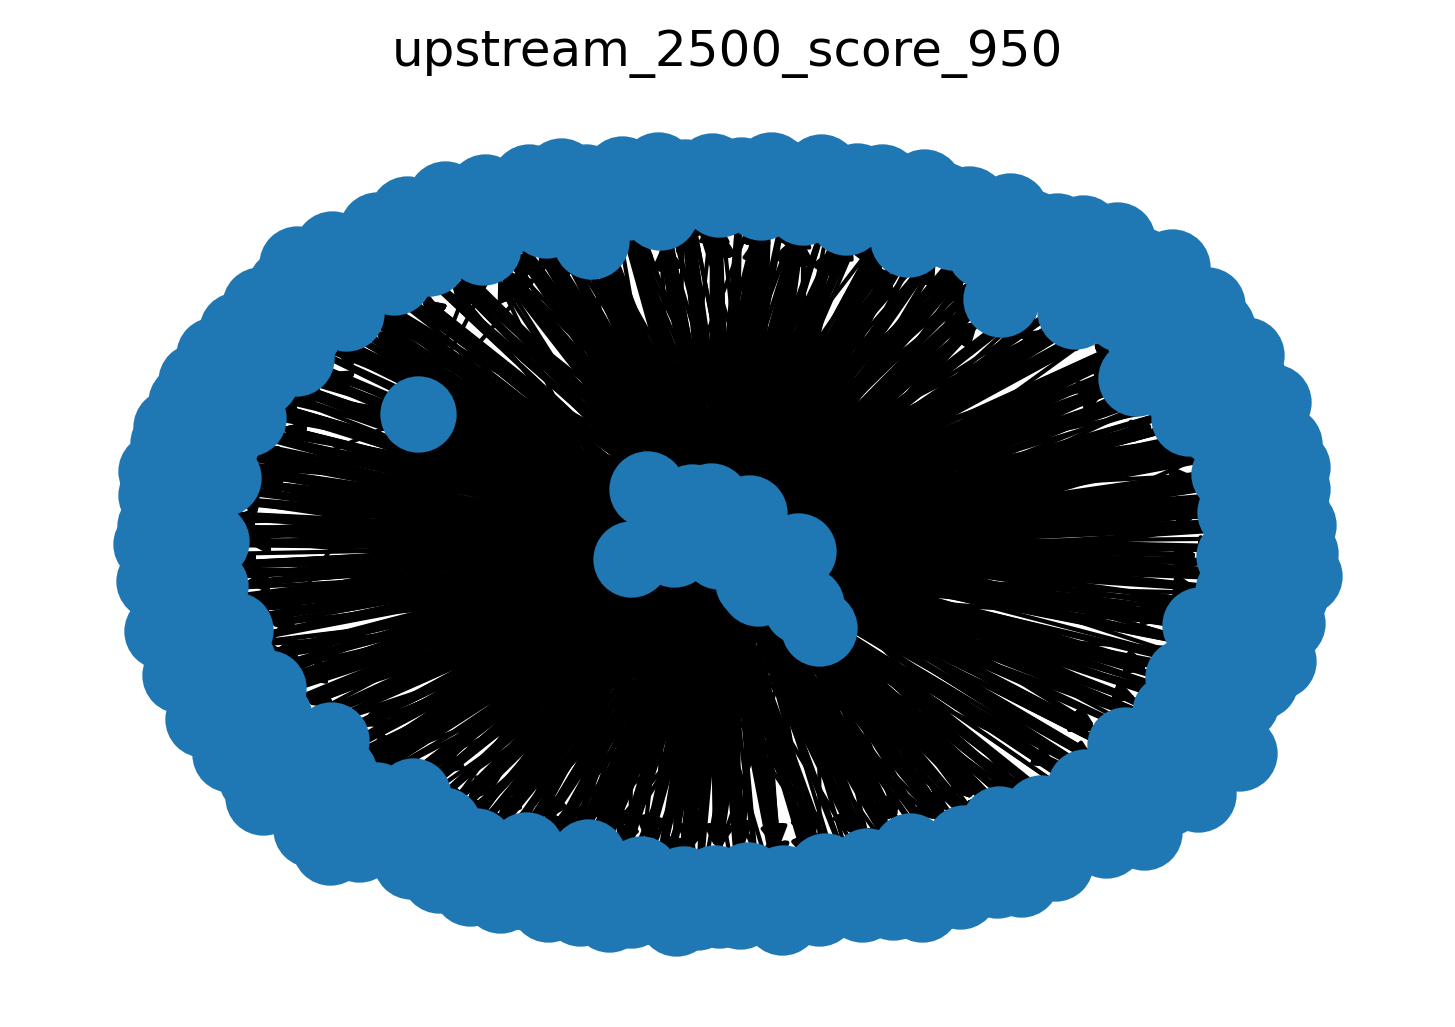

<Figure size 1800x1200 with 0 Axes>

Text(0.5, 1.0, 'upstream_5000_score_950')

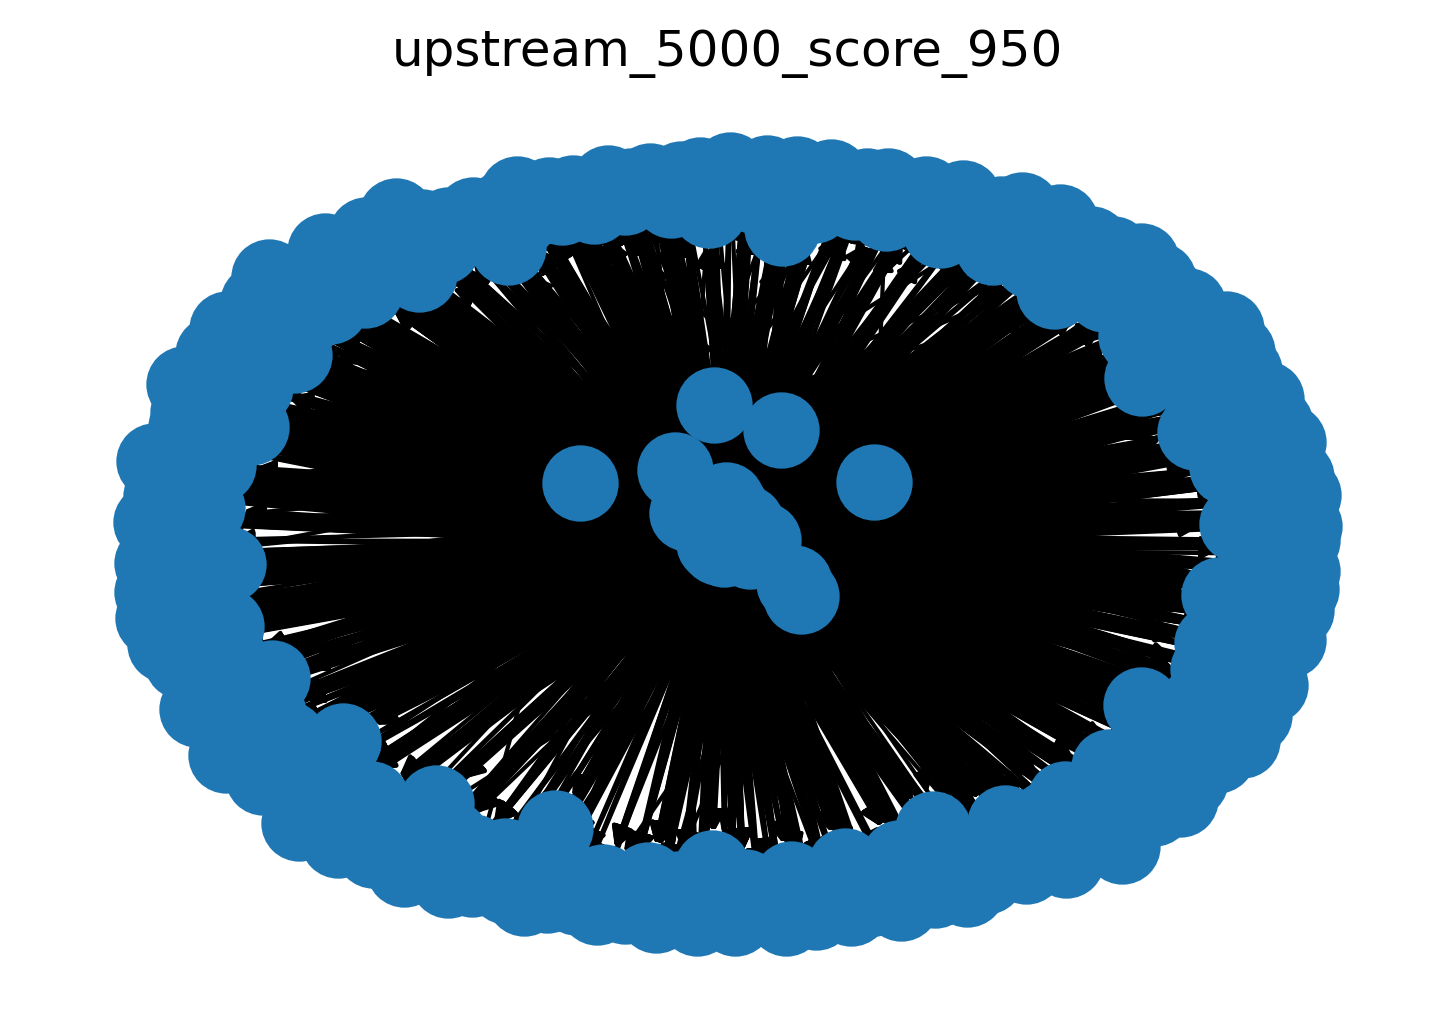

<Figure size 1800x1200 with 0 Axes>

Text(0.5, 1.0, 'upstream_750_score_990')

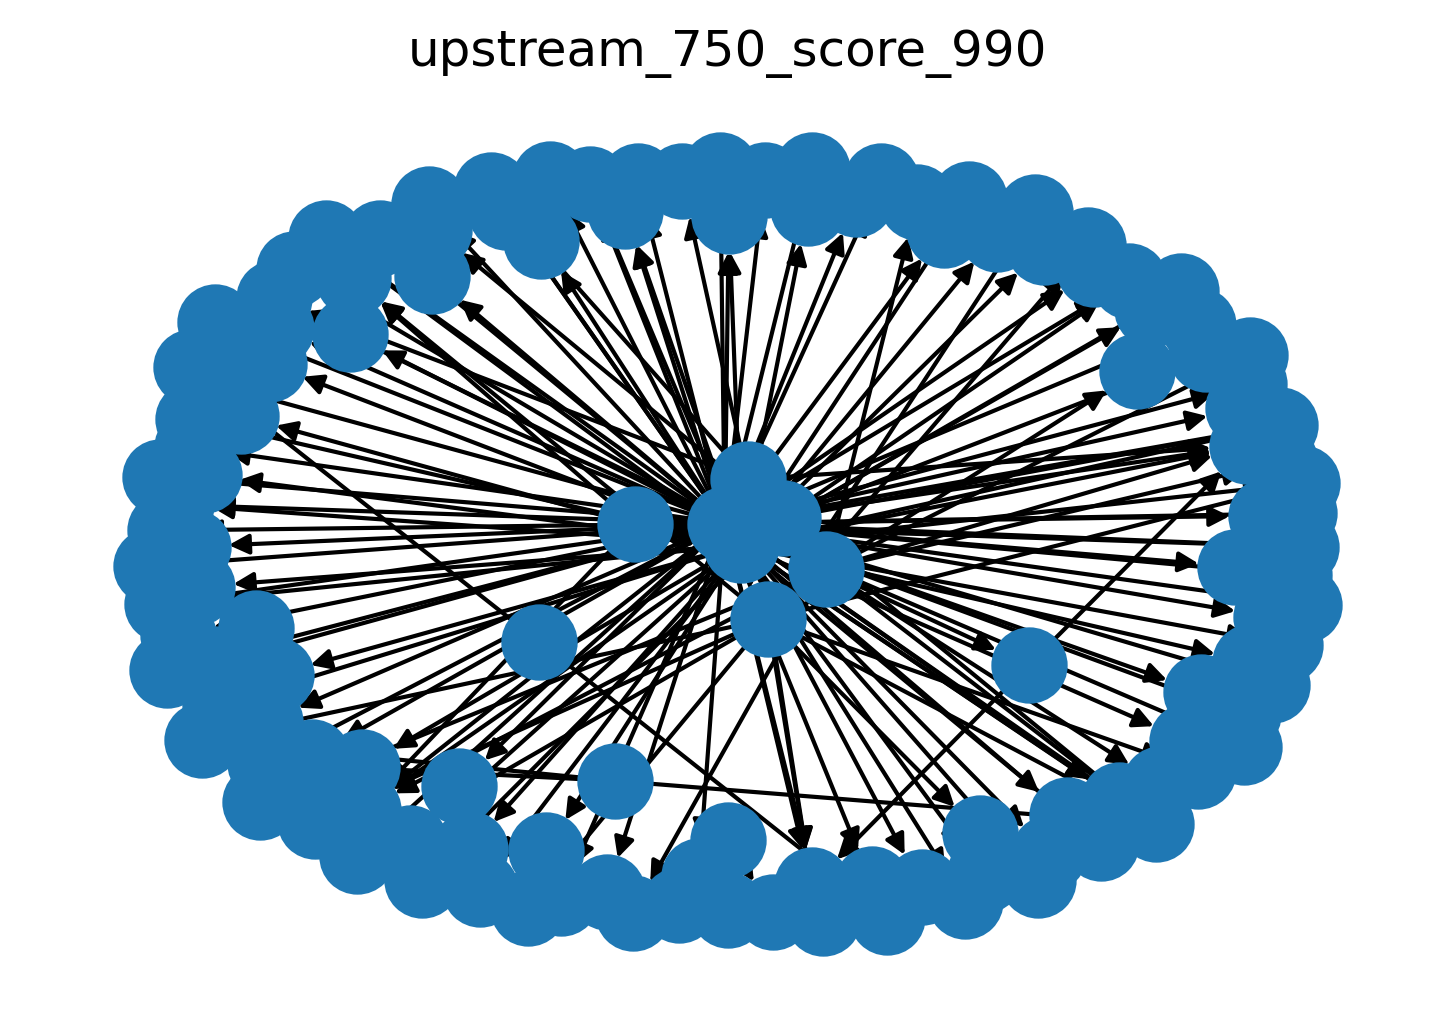

<Figure size 1800x1200 with 0 Axes>

Text(0.5, 1.0, 'upstream_2500_score_990')

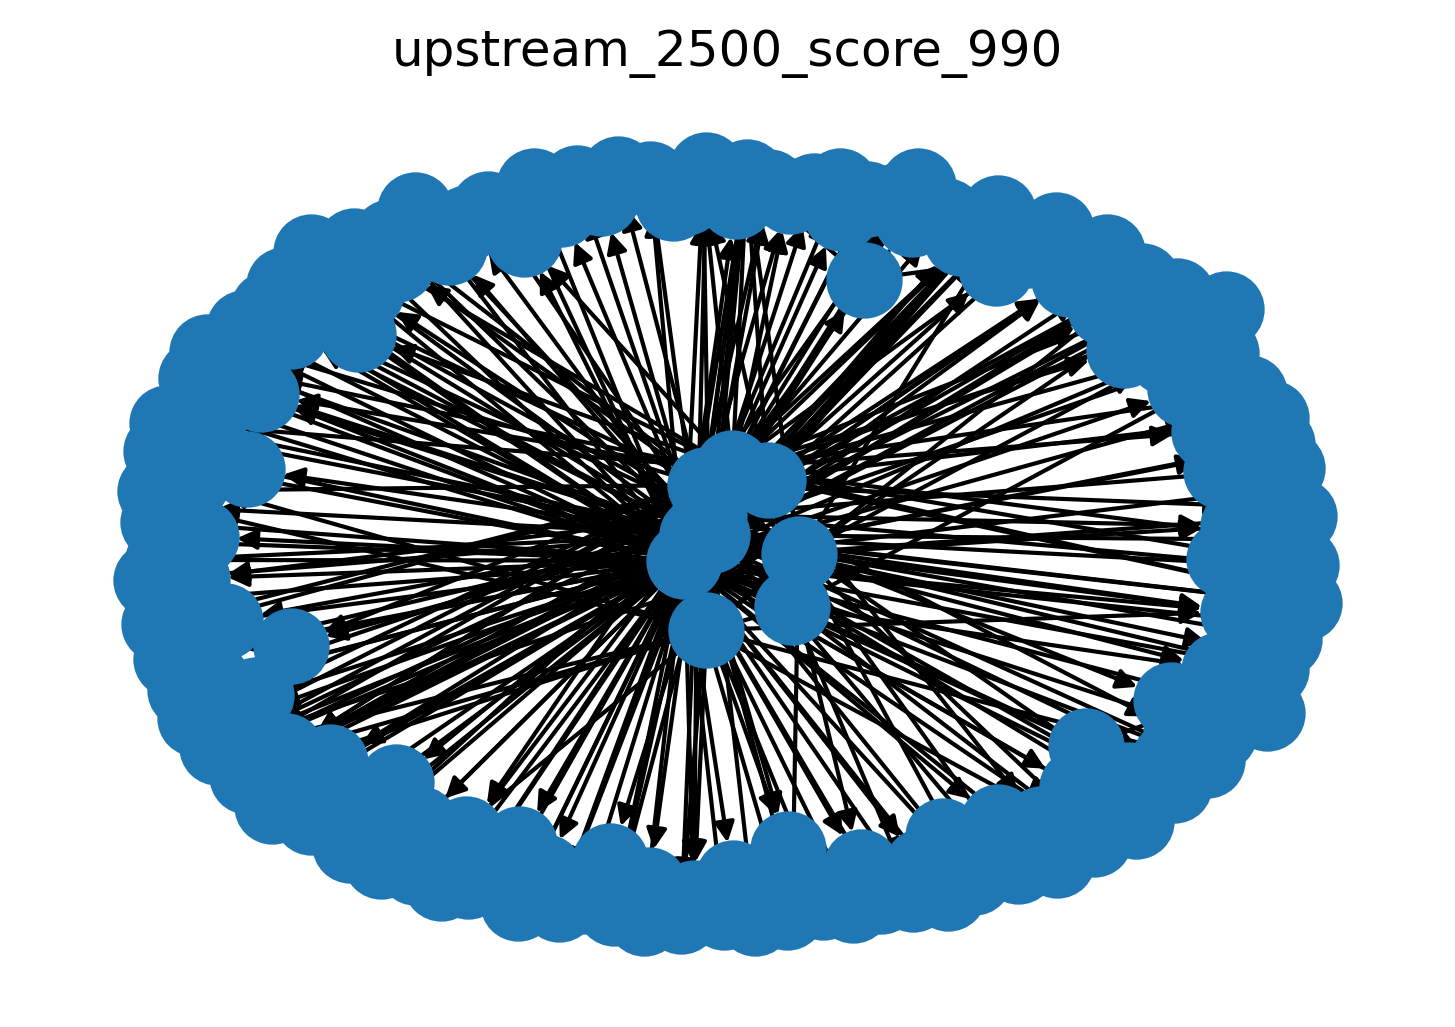

<Figure size 1800x1200 with 0 Axes>

Text(0.5, 1.0, 'upstream_5000_score_990')

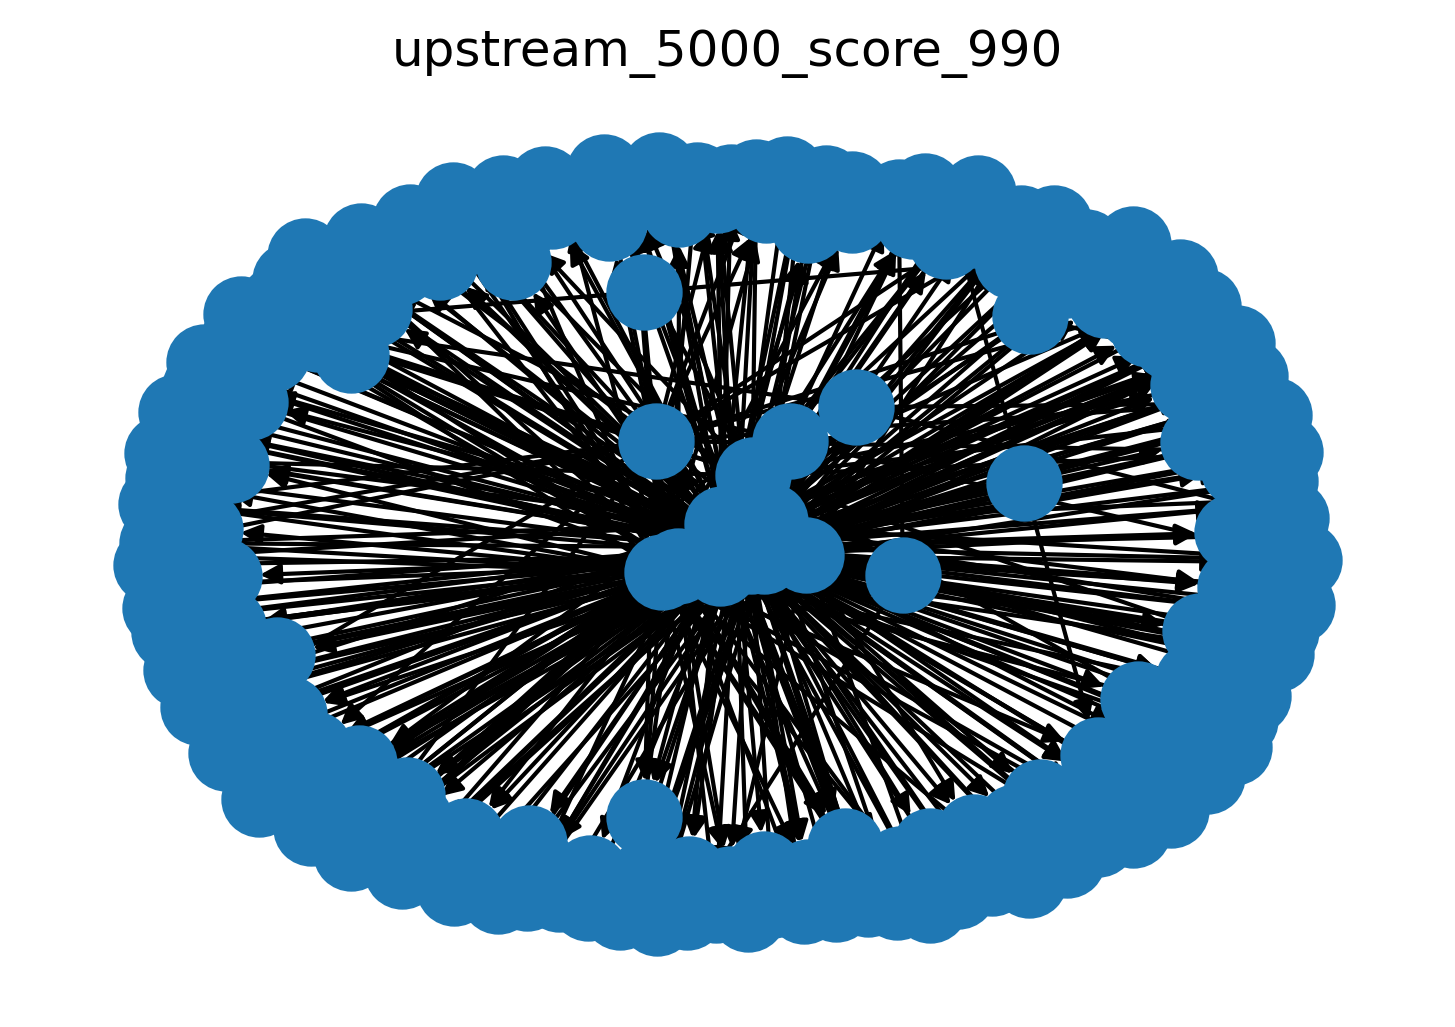

In [21]:
differential_expression_tf_networks = {}

for key in joined_final_edge_lists: 
    tmp = nx.from_pandas_edgelist(joined_final_edge_lists[key], source="TF", target="Target", create_using=nx.DiGraph())
    differential_expression_tf_networks[key] = tmp
    
    plt.figure(dpi=300)
    plt.title(key)
    nx.draw(tmp, pos= nx.spring_layout(tmp))
    plt.show()

## Output Networks in Pickled Format

In [29]:
for key in differential_expression_tf_networks: 
    
    pickle.dump(
        differential_expression_tf_networks[key],
        open(
            "../../../../outputs/differential_expression_tf_networks/{}.networkx_graph".format(key), 
            'wb'
        )
    )

In [35]:
tmp = pickle.load(open("../../../../outputs/differential_expression_tf_networks/upstream_5000_score_900.networkx_graph", 'rb'))

for i in range(0,1000): 
    _ = nx.community.louvain_communities(tmp)
    i

0

1

2

3

4

...

65

66

67

68

KeyboardInterrupt: 

## Louvain Clustering

Only shown here as an example. 

Louvain clustering is done iteratively in the next step with `GO` analysis to find robust terms specific to certain clusters. 

In [37]:
louvain_clustered_items = {}

for key in differential_expression_tf_networks:
    tmp = nx.community.louvain_communities(differential_expression_tf_networks[key], resolution = 1)
    
    louvain_clustered_items[key] = tmp
    

In [ ]:
for parameter_combo in louvain_clustered_items: 
    
    graph_colors = []
    
    rand_colors = randomcolor.RandomColor()
    color_list = rand_colors.generate(count=len(louvain_clustered_items[parameter_combo]))
    
    for node in differential_expression_tf_networks[parameter_combo]: 
        for node_set in louvain_clustered_items[parameter_combo]: 
            if node in node_set: 
                graph_colors.append(color_list[louvain_clustered_items[parameter_combo].index(node_set)])
                break
    
    plt.figure(dpi=200)
    plt.title(parameter_combo)
    nx.draw(differential_expression_tf_networks[parameter_combo], node_color=graph_colors)
    plt.show()

## gProfiler

Run `Louvain clustering` 1000 times and run `gProfiler` each time. 

The goal is to see if there are clusters that reproducibly have certain terms. 

In [47]:
for 

[{'apom',
  'axin2',
  'cadm3',
  'col3a1',
  'crebrf',
  'edn1',
  'eml5',
  'foxa3',
  'fsd1l',
  'gfpt1',
  'hipk2',
  'lamc1',
  'ldlr',
  'lrrfip1',
  'map1a',
  'map1b',
  'myh11',
  'nfic',
  'nfkbiz',
  'npas4',
  'onecut2',
  'plk1',
  'scd2',
  'serpinb6b',
  'spats2l',
  'timp3',
  'tm4sf1',
  'tuft1'},
 {'actn2',
  'adam33',
  'adamts9',
  'akr1c19',
  'ankrd1',
  'car7',
  'cyp26b1',
  'dhcr24',
  'dusp8',
  'fabp4',
  'fads2',
  'fasn',
  'gnas',
  'grip2',
  'mllt11',
  'mttp',
  'mvb12b',
  'pdp2',
  'psd',
  'rnf207',
  'rsad2',
  'samd5',
  'sfrp1',
  'sox4',
  'sprr2h',
  'tmem71',
  'tmsb4x',
  'ttl',
  'ulbp1'},
 {'adnp',
  'alox12',
  'amer1',
  'cbln1',
  'col5a1',
  'cubn',
  'ddt',
  'efnb1',
  'elf4',
  'erv3',
  'fam222a',
  'foxa2',
  'fst',
  'fzd7',
  'galnt10',
  'gipr',
  'h1f0',
  'h1f10',
  'hoxb4',
  'ier3',
  'igf2',
  'krt19',
  'lacc1',
  'lgals1',
  'lratd1',
  'maz',
  'mdk',
  'myh7b',
  'noct',
  'nr2f1',
  'onecut3',
  'ppp2r2c',
  'prkag3',
 

In [46]:
gprofiler_dict = {}

for parameter_combo in louvain_clustered_items: 
    parameter_combo
    
    gprofiler_dict[parameter_combo] = {}
    
    for i in range(0,1000): 
        
        tmp = nx.community.louvain_communities(differential_expression_tf_networks[key], seed=i)
        
        gprofiler_dict[parameter_combo]["iter {}".format(i)] = {}
        
        counter = 0 
        
        for node_set in tmp:
            counter+=1
            
            counter

            gp = GProfiler(return_dataframe=True)
            gprofiler_dict[parameter_combo]["iter {}".format(i)]["cluster {}".format(counter)] = {}

            gprofiler_dict[parameter_combo]["iter {}".format(i)]["cluster {}".format(counter)]["input"] = node_set
            gprofiler_dict[parameter_combo]["iter {}".format(i)]["cluster {}".format(counter)]["results"] = gp.profile(organism='mmusculus', query=list(node_set), no_evidences=False)

'upstream_750_score_900'

1

2

3

KeyboardInterrupt: 

In [ ]:
counter = 0

for parameter_combo in gprofiler_dict: 
    assert len(gprofiler_dict[parameter_combo]) > 0
    
    parameter_combo
    
    for iteration in gprofiler_dict[parameter_combo]:
        assert len(gprofiler_dict[parameter_combo][iteration])>0
        
        for cluster in gprofiler_dict[parameter_combo][iteration]: 
            
            if "input" not in gprofiler_dict[parameter_combo][iteration][cluster] or "results" not in gprofiler_dict[parameter_combo][iteration][cluster]: 
                parameter_combo, iteration, cluster
            
#             assert len(gprofiler_dict[parameter_combo][iteration][cluster]["input"])>0
                        
#             if len(gprofiler_dict[parameter_combo][iteration][cluster]["results"])==0: 
#                 assert len(gprofiler_dict[parameter_combo][iteration][cluster]["results"].columns)>0
                
                
counter

In [ ]:
for parameter_combo in gprofiler_dict: 
    for cluster in gprofiler_dict[parameter_combo]: 
        tmp = gprofiler_dict[parameter_combo][cluster]['results']
        
        query = tmp[
            tmp["name"].str.contains("heart", case=False) | 
            tmp["name"].str.contains("vascul", case=False) |
            tmp["name"].str.contains("blood", case=False) | 
            tmp["name"].str.contains("circulat", case=False)
        ]
        
        if query.index.size>0: 
            "{} {} {}".format(parameter_combo, cluster, gprofiler_dict[parameter_combo][cluster]["input"])
            
            query


In [ ]:
len(gprofiler_dict["upstream_750_score_990"])

print(gprofiler_dict["upstream_750_score_990"]["cluster 1"]["input"], end="\t")

In [ ]:

for cluster in gprofiler_dict["upstream_750_score_990"]: 
    gprofiler_dict["upstream_750_score_990"][cluster]["results"]

In [ ]:
nx.community.modularity(differential_expression_tf_networks["upstream_750_score_990"], louvain_clustered_items["upstream_750_score_990"])

## TF-TF Networks

In [ ]:
mouse_tfs.head()

In [ ]:
for key in final_edge_lists: 
    final_edge_lists[key].index.size
    final_edge_lists[key].join(mouse_tfs, how="inner").head()
    
    